In [138]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]


In [139]:
np.random.seed(1234)

fields = []

min, max = -(D+3.), -1.
NUM = 10
alphas = np.linspace(max, min, NUM)

for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in reciprocal
  terms.append((xx/bb[0])**(-a[0]))
/home/m/Documents/science_codes/Kea/Kea/simulator/fbm.py:62: RuntimeWarning: invalid value encountered in multiply
  output = np.sqrt(output * C)
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in power
  terms.append((xx/bb[0])**(-a[0]))


In [140]:

kfeks = []

for f in fields:
    k, fek, _ = spectra_base.calculate_integrated_spectrum((f,), spec_type='modal', lenn=phys_dims)
    kfeks.append((k, fek))


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, 

In [141]:

sfs = []

for f in fields:
    lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in f.shape])
    sf2 = strfn.process_lags(f, f, lv2, periodic=True, lenn=phys_dims, shape=tuple([2*n+1 for n in f.shape]), orders=[2])[0]
    sfs.append(sf2)


In [142]:

lsf = []

for fs in sfs:
    lvm = statfunc_base.get_lagvec_magnitude_array(fs.shape)
    l, sf, _ = statistics_base.bin_data(lvm, fs, mean_func=np.nanmean, cut_excess=True, min_bin=1., ignore_nan=True)
    lsf.append((l, sf))


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, 

Text(0.5, 1.0, '-5.114609619735237 - -5.0 = -0.11460961973523709')

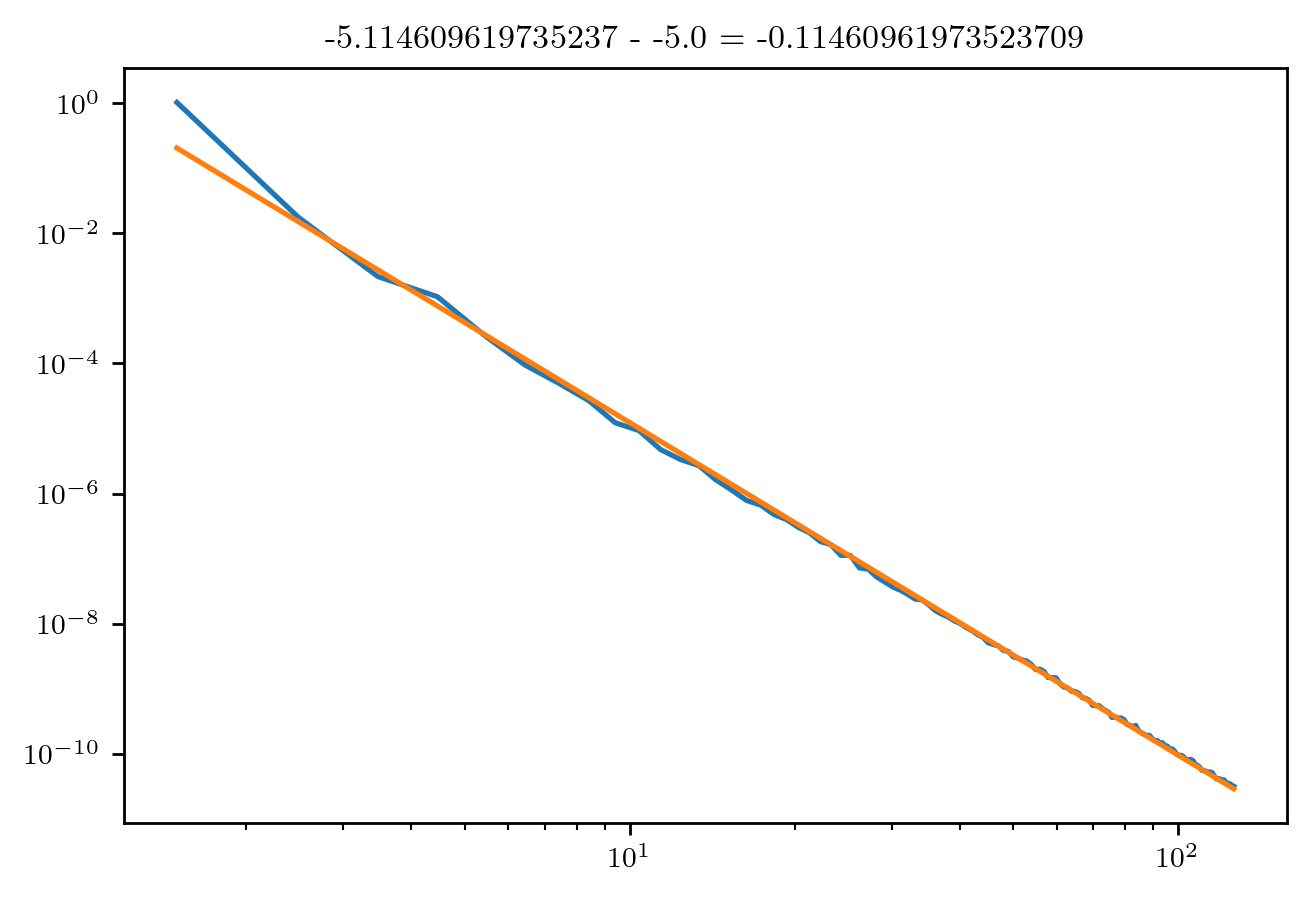

In [143]:
idx = 9
k, fek = kfeks[idx]
plt.loglog(k, fek)
z, xx, p = fit_base.fit_powerlaw(k, fek,np.nanmin(k), np.nanmax(k))
plt.loglog(xx, p)
plt.title('%s - %s = %s' % (z[0], alphas[idx], z[0] - alphas[idx]))

Text(0.5, 1.0, '0.49090892643133843 - 0.33333333333333304 = 0.1575755930980054')

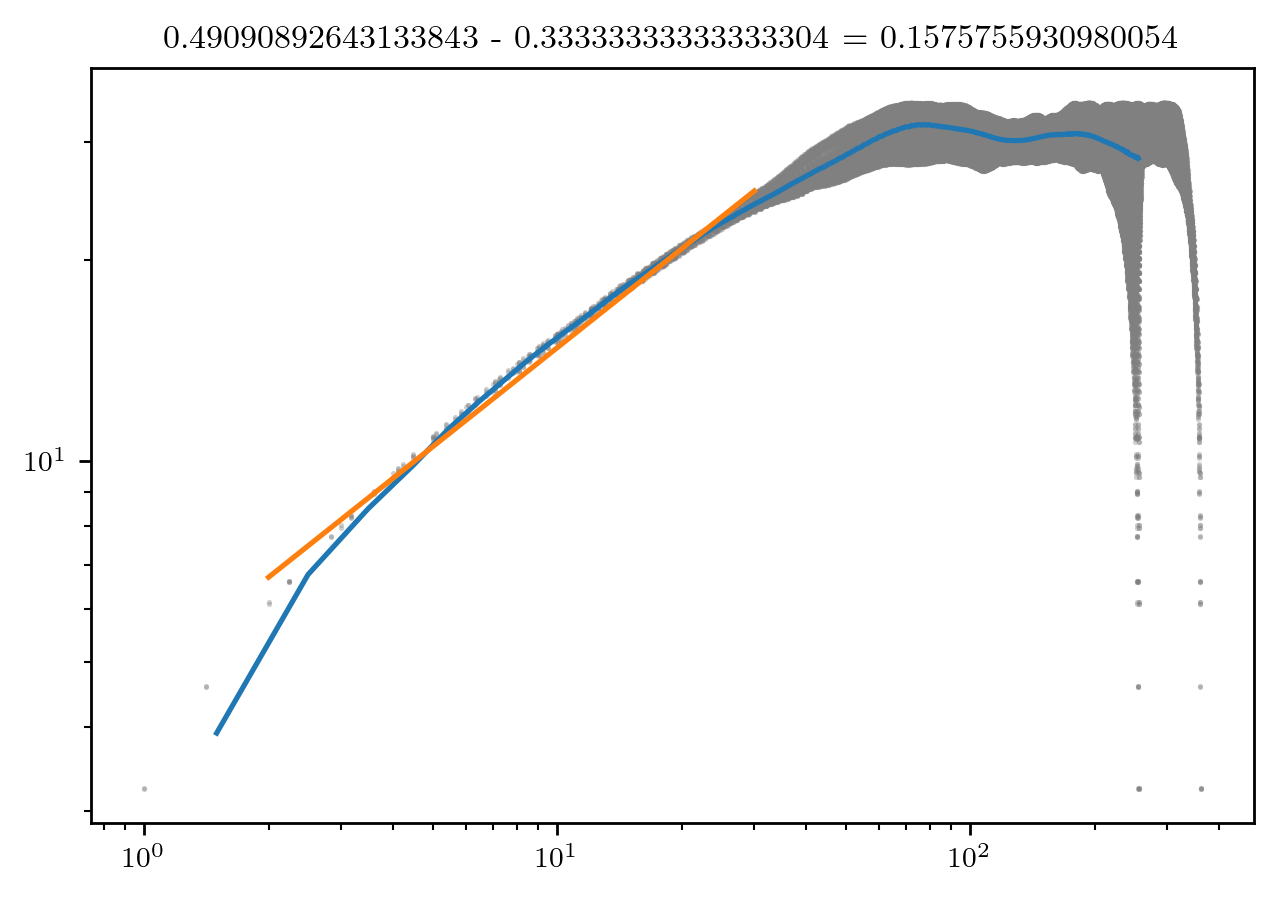

In [151]:

idx = 3
k, fek = lsf[idx]
plt.scatter(lvm, sfs[idx], alpha=0.2, color='gray', marker='.', s=1.)
plt.loglog(k, fek)
z, xx, p = fit_base.fit_powerlaw(k, fek, 2., 30.)
plt.loglog(xx, p)
#z, xx, p = fit_base.fit_powerlaw(k, fek, 2., 10.)
#plt.loglog(xx, p)

# beta = E + 2H
# gamma = 2H
# -> gamma = 2H = beta - E
# for beta \in [E, ..., E + 2] = [2, ..., 4]

beta = - alphas[idx]
plt.title('%s - %s = %s' % (z[0], beta - D, z[0] - (beta - D)))


In [149]:

sf_pwrl = {}

for i, ll in enumerate(lsf):
    l, sf = ll
    z, xx, p = fit_base.fit_powerlaw(l, sf, 2., 30.)
    sf_pwrl[-alphas[i]] = (z[0], - alphas[i] - D)

ek_pwrl = {}

for i, kfek in enumerate(kfeks):
    k, fek = kfek
    z, xx, p = fit_base.fit_powerlaw(k, fek, np.nanmin(k), np.nanmax(k))
    ek_pwrl[-alphas[i]] = (z[0], alphas[i])


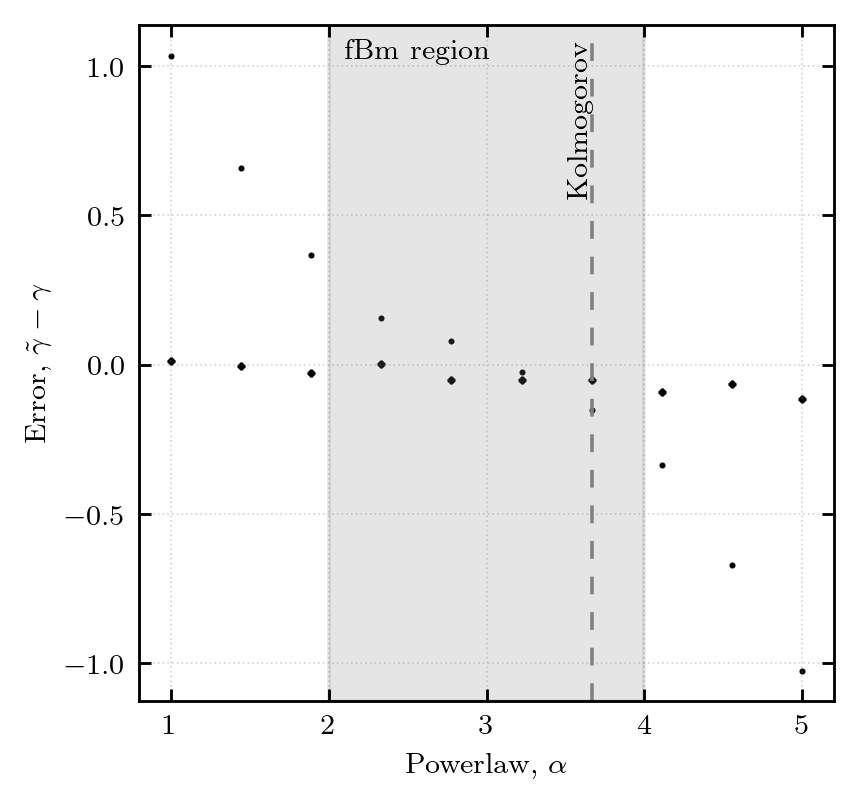

In [150]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for a in sf_pwrl.keys():
    #ax.scatter(a, pwrl[a][0]/pwrl[a][1], marker='.', s=2., color='black')
    ax.scatter(a, sf_pwrl[a][0] - sf_pwrl[a][1], marker='.', s=2., color='black')

for a in ek_pwrl.keys():
    ax.scatter(a, ek_pwrl[a][0] - ek_pwrl[a][1], marker='x', s=2., color='black')

ax.axvline(11./3., linestyle=(0, (5, 5)), color='gray', linewidth=1.)
ax.text(11./3.-0.15, 0.75, r'Kolmogorov', transform=ax.get_xaxis_transform(), rotation=90, color='black')

ax.axvspan(D, D+2., alpha=0.2, color='gray')
ax.text(2.1, 0.95, r'fBm region', transform=ax.get_xaxis_transform(), color='black')

#ax.set_ylabel('Bias, $\\tilde{\gamma}/\gamma$')
ax.set_ylabel('Error, $\\tilde{\gamma} - \gamma$')
ax.set_xlabel('Powerlaw, $\\alpha$')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='x', direction='in')

ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')